# Assignment 3: Motif Discovery

This notebook solves the motif discovery assignment using:

1. **Greedy Motif Search** (profile-matrix-based scoring)
2. **Median String Algorithm** (Hamming-distance-based scoring)

We use motif length **k = 6**, track operation counters for empirical complexity, and show how scores vary across computation steps.

In [6]:
# Standard imports only for file handling and visualization of score trends.
# Core motif logic is implemented manually (no built-in motif discovery libraries).
from pathlib import Path
import time

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    HAS_MATPLOTLIB = False

K = 6
DNA_FILE = Path('dna.txt')


def read_dna_sequences(path: Path):
    """Read DNA sequences from a plain-text file (one sequence per line)."""
    sequences = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            s = line.strip().lower()
            if s:
                sequences.append(s)
    return sequences


dna = read_dna_sequences(DNA_FILE)
T = len(dna)
N = len(dna[0]) if dna else 0

print(f"Loaded {T} DNA sequences")
print(f"Sequence length (assumed equal): {N}")
print(f"Motif length k: {K}")

Loaded 26 DNA sequences
Sequence length (assumed equal): 40
Motif length k: 6


## Shared Utility Functions

These helper functions are used by both algorithms:

- Hamming distance
- Motif/profile scoring
- Most probable k-mer selection
- Candidate generation for median-string search (`4^k` patterns)

In [7]:
class OpCounter:
    """Lightweight operation counter for empirical time-complexity estimation."""
    def __init__(self):
        self.count = 0

    def add(self, n=1):
        self.count += n


def hamming_distance(a, b, counter=None):
    """Compute Hamming distance between two equal-length strings."""
    if len(a) != len(b):
        raise ValueError('Strings must have equal length for Hamming distance.')

    dist = 0
    for i in range(len(a)):
        if counter:
            counter.add(1)
        if a[i] != b[i]:
            dist += 1
    return dist


def build_profile(motifs, pseudocount=1):
    """Build profile matrix with optional pseudocounts to avoid zero probabilities."""
    k = len(motifs[0])
    profile = {
        'a': [pseudocount] * k,
        'c': [pseudocount] * k,
        'g': [pseudocount] * k,
        't': [pseudocount] * k,
    }

    for motif in motifs:
        for j, ch in enumerate(motif):
            profile[ch][j] += 1

    denom = len(motifs) + 4 * pseudocount
    for base in 'acgt':
        for j in range(k):
            profile[base][j] = profile[base][j] / denom

    return profile


def motif_score_profile_based(motifs):
    """
    Profile-matrix-based score:
    Sum over columns of (number of strings - max base count in that column).
    Lower score is better.
    """
    k = len(motifs[0])
    t = len(motifs)
    score = 0
    for j in range(k):
        counts = {'a': 0, 'c': 0, 'g': 0, 't': 0}
        for motif in motifs:
            counts[motif[j]] += 1
        col_max = max(counts.values())
        score += (t - col_max)
    return score


def consensus_from_motifs(motifs):
    """Get consensus string from motifs by majority vote per column."""
    k = len(motifs[0])
    cons = []
    for j in range(k):
        counts = {'a': 0, 'c': 0, 'g': 0, 't': 0}
        for motif in motifs:
            counts[motif[j]] += 1
        best_base = 'a'
        best_count = counts['a']
        for b in 'cgt':
            if counts[b] > best_count:
                best_count = counts[b]
                best_base = b
        cons.append(best_base)
    return ''.join(cons)


def kmer_probability(kmer, profile, counter=None):
    """Compute probability of a k-mer under a profile matrix."""
    p = 1.0
    for j, ch in enumerate(kmer):
        if counter:
            counter.add(1)
        p *= profile[ch][j]
    return p


def most_probable_kmer(sequence, k, profile, counter=None):
    """
    Return the profile-most-probable k-mer in a sequence.
    Ties are broken by first occurrence.
    """
    best = sequence[0:k]
    best_p = kmer_probability(best, profile, counter=counter)

    for i in range(1, len(sequence) - k + 1):
        if counter:
            counter.add(1)
        candidate = sequence[i:i + k]
        p = kmer_probability(candidate, profile, counter=counter)
        if p > best_p:
            best_p = p
            best = candidate

    return best


def generate_all_kmers(k):
    """Generate all 4^k DNA strings over alphabet {a,c,g,t}."""
    alphabet = ['a', 'c', 'g', 't']
    patterns = ['']
    for _ in range(k):
        new_patterns = []
        for p in patterns:
            for ch in alphabet:
                new_patterns.append(p + ch)
        patterns = new_patterns
    return patterns


def distance_pattern_to_sequence(pattern, sequence, counter=None):
    """Minimum Hamming distance between pattern and any k-mer window in one sequence."""
    k = len(pattern)
    best = None
    for i in range(len(sequence) - k + 1):
        if counter:
            counter.add(1)
        d = hamming_distance(pattern, sequence[i:i + k], counter=counter)
        if best is None or d < best:
            best = d
    return best


def total_distance_pattern_to_dna(pattern, dna_list, counter=None):
    """Sum of minimum distances between pattern and each sequence in dna_list."""
    total = 0
    for seq in dna_list:
        total += distance_pattern_to_sequence(pattern, seq, counter=counter)
    return total

## Greedy Motif Search

Approach:

1. Start with each possible `k`-mer from the first sequence as a seed.
2. Iteratively build motifs for remaining sequences using profile-most-probable `k`-mers.
3. Compute profile-based score and keep the best motif set.
4. Track score after each seed expansion to observe convergence behavior.

Greedy Motif Search Results
----------------------------------------
Best profile-based score: 21
Consensus motif: gggcaa
Empirical operation count: 213535
Runtime (seconds): 0.060427

Best motifs:
Seq 01: gggcaa
Seq 02: gggcca
Seq 03: atgcaa
Seq 04: gggcaa
Seq 05: cgggaa
Seq 06: gggcaa
Seq 07: gggcaa
Seq 08: gggcaa
Seq 09: ggtcaa
Seq 10: gggtaa
Seq 11: gggcta
Seq 12: gtgcaa
Seq 13: gttcaa
Seq 14: gggcga
Seq 15: gggcaa
Seq 16: gggaga
Seq 17: gagcaa
Seq 18: gggcca
Seq 19: gggcta
Seq 20: ggccaa
Seq 21: gggcaa
Seq 22: gggcaa
Seq 23: gggcaa
Seq 24: cggcaa
Seq 25: ggtcaa
Seq 26: gggtaa

Score history snapshot (first 20):
[101, 61, 55, 55, 49, 47, 40, 25, 24, 22, 52, 64, 52, 55, 46, 59, 60, 41, 44, 51]
Score history snapshot (last 20):
[60, 41, 44, 51, 57, 53, 59, 63, 56, 42, 40, 25, 24, 21, 35, 42, 50, 56, 31, 28]


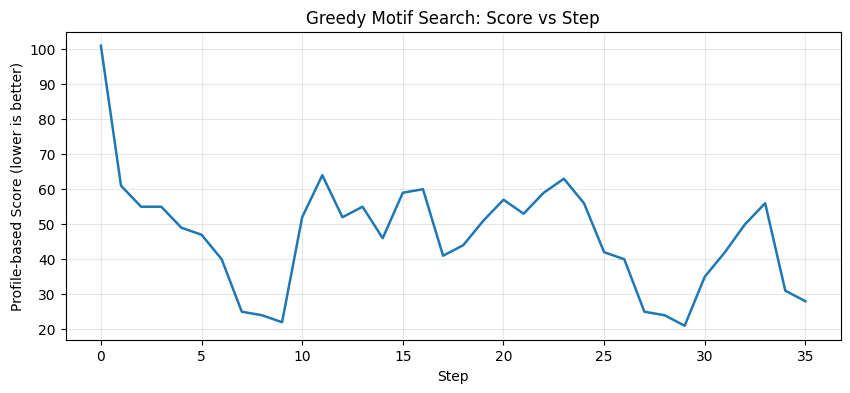

In [8]:
def greedy_motif_search(dna_list, k, pseudocount=1):
    """Greedy motif search with profile matrix and empirical operation counting."""
    counter = OpCounter()
    t = len(dna_list)

    # Initial motifs: first k-mer from each sequence.
    best_motifs = [seq[0:k] for seq in dna_list]
    best_score = motif_score_profile_based(best_motifs)

    # Track score progression as computation proceeds.
    score_history = [best_score]

    start = time.perf_counter()

    first_seq = dna_list[0]
    for i in range(len(first_seq) - k + 1):
        counter.add(1)
        motifs = [first_seq[i:i + k]]

        # Build motifs greedily for sequence 2..t.
        for j in range(1, t):
            profile = build_profile(motifs, pseudocount=pseudocount)
            next_motif = most_probable_kmer(dna_list[j], k, profile, counter=counter)
            motifs.append(next_motif)

        current_score = motif_score_profile_based(motifs)
        score_history.append(current_score)

        if current_score < best_score:
            best_score = current_score
            best_motifs = motifs[:]

    elapsed = time.perf_counter() - start

    return {
        'best_motifs': best_motifs,
        'consensus': consensus_from_motifs(best_motifs),
        'best_score': best_score,
        'score_history': score_history,
        'operation_count': counter.count,
        'elapsed_seconds': elapsed,
    }


greedy_result = greedy_motif_search(dna, K, pseudocount=1)

print('Greedy Motif Search Results')
print('-' * 40)
print(f"Best profile-based score: {greedy_result['best_score']}")
print(f"Consensus motif: {greedy_result['consensus']}")
print(f"Empirical operation count: {greedy_result['operation_count']}")
print(f"Runtime (seconds): {greedy_result['elapsed_seconds']:.6f}")
print('\nBest motifs:')
for idx, m in enumerate(greedy_result['best_motifs'], start=1):
    print(f"Seq {idx:02d}: {m}")

print('\nScore history snapshot (first 20):')
print(greedy_result['score_history'][:20])
print('Score history snapshot (last 20):')
print(greedy_result['score_history'][-20:])

if HAS_MATPLOTLIB:
    plt.figure(figsize=(10, 4))
    plt.plot(greedy_result['score_history'], linewidth=1.8)
    plt.title('Greedy Motif Search: Score vs Step')
    plt.xlabel('Step')
    plt.ylabel('Profile-based Score (lower is better)')
    plt.grid(alpha=0.3)
    plt.show()

### Greedy Convergence Comment

In Greedy search, score often drops quickly in early steps and then stabilizes, because once a strong seed is found the best score is hard to improve further. This behavior appears as a curve that tends to flatten (partial convergence), though local-optimum trapping is possible.

## Median String Algorithm

Approach:

1. Generate all possible reference motifs of length `k` (`4^k` candidates).
2. For each candidate, compute total Hamming-distance score to all sequences:
   - For each sequence, take minimum distance across all windows.
3. Select the candidate with the minimum total distance.
4. Track score for each candidate step to show variation with progress.

Median String Results
----------------------------------------
Best median string: gggcaa
Best Hamming-distance score: 21
Empirical operation count: 26095616
Runtime (seconds): 2.287531

Best matching window in each sequence (window, distance):
Seq 01: (gggcaa, 0)
Seq 02: (gggcca, 1)
Seq 03: (atgcaa, 2)
Seq 04: (gggcaa, 0)
Seq 05: (gggtac, 2)
Seq 06: (gggcaa, 0)
Seq 07: (gggcaa, 0)
Seq 08: (gggcaa, 0)
Seq 09: (ggtcaa, 1)
Seq 10: (gggtaa, 1)
Seq 11: (gggcta, 1)
Seq 12: (gtgcaa, 1)
Seq 13: (cgggaa, 2)
Seq 14: (gggcga, 1)
Seq 15: (gggcaa, 0)
Seq 16: (ggggag, 2)
Seq 17: (gagcaa, 1)
Seq 18: (ggggaa, 1)
Seq 19: (gggcta, 1)
Seq 20: (ggccaa, 1)
Seq 21: (gggcaa, 0)
Seq 22: (gggcaa, 0)
Seq 23: (gggcaa, 0)
Seq 24: (tggcaa, 1)
Seq 25: (ggtcaa, 1)
Seq 26: (gggtaa, 1)

Score history snapshot (first 20):
[58, 54, 49, 52, 48, 53, 47, 46, 45, 52, 46, 47, 49, 52, 49, 53, 56, 53, 51, 48]
Score history snapshot (last 20):
[56, 60, 55, 62, 54, 64, 58, 64, 61, 66, 62, 69, 52, 62, 58, 65, 61, 68, 60, 75]


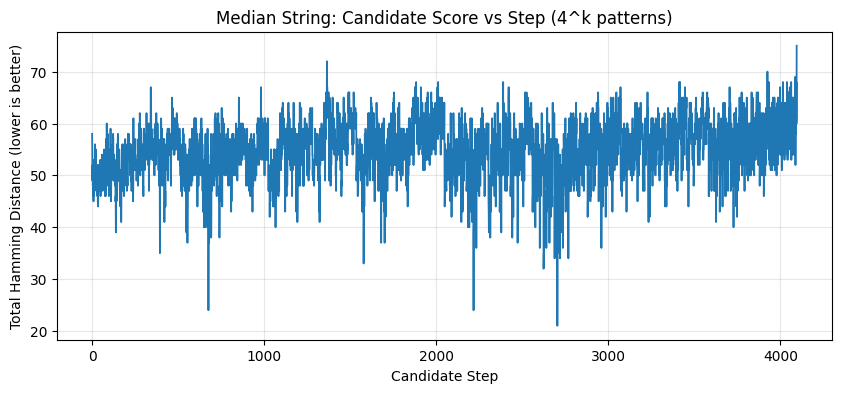

In [9]:
def median_string_search(dna_list, k):
    """Median string search over all 4^k candidates with operation counting."""
    counter = OpCounter()
    candidates = generate_all_kmers(k)

    best_pattern = None
    best_score = None
    score_history = []

    start = time.perf_counter()

    for pattern in candidates:
        counter.add(1)
        score = total_distance_pattern_to_dna(pattern, dna_list, counter=counter)
        score_history.append(score)

        if best_score is None or score < best_score:
            best_score = score
            best_pattern = pattern

    elapsed = time.perf_counter() - start

    # For reporting per-sequence chosen motif windows for the winning median pattern.
    chosen_windows = []
    for seq in dna_list:
        min_d = None
        min_w = seq[0:k]
        for i in range(len(seq) - k + 1):
            w = seq[i:i + k]
            d = hamming_distance(best_pattern, w)
            if min_d is None or d < min_d:
                min_d = d
                min_w = w
        chosen_windows.append((min_w, min_d))

    return {
        'best_pattern': best_pattern,
        'best_score': best_score,
        'score_history': score_history,
        'operation_count': counter.count,
        'elapsed_seconds': elapsed,
        'chosen_windows': chosen_windows,
    }


median_result = median_string_search(dna, K)

print('Median String Results')
print('-' * 40)
print(f"Best median string: {median_result['best_pattern']}")
print(f"Best Hamming-distance score: {median_result['best_score']}")
print(f"Empirical operation count: {median_result['operation_count']}")
print(f"Runtime (seconds): {median_result['elapsed_seconds']:.6f}")

print('\nBest matching window in each sequence (window, distance):')
for idx, (w, d) in enumerate(median_result['chosen_windows'], start=1):
    print(f"Seq {idx:02d}: ({w}, {d})")

print('\nScore history snapshot (first 20):')
print(median_result['score_history'][:20])
print('Score history snapshot (last 20):')
print(median_result['score_history'][-20:])

if HAS_MATPLOTLIB:
    plt.figure(figsize=(10, 4))
    plt.plot(median_result['score_history'], linewidth=1.3)
    plt.title('Median String: Candidate Score vs Step (4^k patterns)')
    plt.xlabel('Candidate Step')
    plt.ylabel('Total Hamming Distance (lower is better)')
    plt.grid(alpha=0.3)
    plt.show()

## Complexity and Requirement Mapping

Let:

- `T` = number of sequences
- `N` = sequence length
- `k` = motif length

### 1) Greedy Motif Search

- Theoretical (dominant term): approximately `O((N-k+1)^2 * T * k)`
- Empirical from counter: printed above as `operation_count`
- Score progression: shown in history list and line plot
- Convergence comment: score tends to flatten after improvements

### 2) Median String

- Number of candidates: `4^k`
- Per-candidate scoring over DNA: `O(T * (N-k+1) * k)`
- Total theoretical: `O(4^k * T * (N-k+1) * k)`
- Empirical from counter: printed above as `operation_count`
- Score variation: shown for every candidate step (`score_history`)

This completes the assignment requirements relevant to the two requested algorithms.

In [10]:
# Final compact summary for quick grading.
print('FINAL SUMMARY')
print('=' * 40)
print(f"Greedy -> consensus: {greedy_result['consensus']}, score: {greedy_result['best_score']}, ops: {greedy_result['operation_count']}, time: {greedy_result['elapsed_seconds']:.6f}s")
print(f"Median -> best pattern: {median_result['best_pattern']}, score: {median_result['best_score']}, ops: {median_result['operation_count']}, time: {median_result['elapsed_seconds']:.6f}s")

FINAL SUMMARY
Greedy -> consensus: gggcaa, score: 21, ops: 213535, time: 0.060427s
Median -> best pattern: gggcaa, score: 21, ops: 26095616, time: 2.287531s
